# This is a 'just for fun' jupyter notebook used to train data science skills and to experiment some new python libraries

![Titanic](https://aventurasnahistoria.uol.com.br/media/_versions/naufragio/titaniammd_widexl.jpg)



## Please: upvote if you liked this work...

![Upvote](https://i.imgur.com/cKIAXRw.jpg)

## Setting up of some libraries

In [1]:
!pip install dabl;

     |████████████████████████████████| 566 kB 417 kB/s 
  Created wheel for dabl: filename=dabl-0.1.9-py3-none-any.whl size=572788 sha256=1db5a2d2fcba019540bcf7c64f83a60d4fb330db9b721fab3fe0069a2b83c137
  Stored in directory: /root/.cache/pip/wheels/aa/38/8f/66d5e159658b37cb0b8f9176a9f584f14bcd5ea0c1e96011bf
Successfully built dabl
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [2]:
!pip install missingno

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [3]:
!pip install ppscore

  Created wheel for ppscore: filename=ppscore-1.1.1-py2.py3-none-any.whl size=12986 sha256=7029cfd8fecca16a68e4196f2a101e1563ea5ba8d104092a6d9882973250dd65
  Stored in directory: /root/.cache/pip/wheels/d0/1f/c4/e619fb20c9b10df8ddde15d583197edef8c2f27d7b1f29c633
Successfully built ppscore
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [4]:
!pip install autoviz

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [5]:
!pip install pycaret

     |████████████████████████████████| 252 kB 417 kB/s 
     |████████████████████████████████| 13.9 MB 12.2 MB/s 
     |████████████████████████████████| 96 kB 3.9 MB/s 
     |████████████████████████████████| 258 kB 18.5 MB/s 
     |████████████████████████████████| 54 kB 1.7 MB/s 
     |████████████████████████████████| 6.0 MB 14.2 MB/s 
     |████████████████████████████████| 326 kB 33.8 MB/s 
     |████████████████████████████████| 77 kB 4.9 MB/s 
     |████████████████████████████████| 1.1 MB 32.0 MB/s 
     |████████████████████████████████| 2.1 MB 27.9 MB/s 
     |████████████████████████████████| 3.1 MB 27.9 MB/s 
     |████████████████████████████████| 64 kB 2.2 MB/s 
     |████████████████████████████████| 122 kB 34.0 MB/s 
     |████████████████████████████████| 84 kB 2.3 MB/s 
     |████████████████████████████████| 45 kB 2.3 MB/s 
  Created wheel for pyod: filename=pyod-0.8.3-py3-none-any.whl size=110347 sha256=e71e06b83dde8cb7fd14bd5e800e7b118c03177ee14b25fe015e4c1d9ae8

In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import dabl
import missingno as msno
from autoviz.AutoViz_Class import AutoViz_Class
import ppscore as pps

from sklearn.preprocessing import LabelEncoder
from pycaret import classification

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



Imported AutoViz_Class version: 0.0.71. Call using:
    from autoviz.AutoViz_Class import AutoViz_Class
    AV = AutoViz_Class()
    AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=0,
                            lowess=False,chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30)
            
To remove previous versions, perform 'pip uninstall autoviz'
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


# 1. Problem definition

## Need statement: Given a Titanic passenger database, create a predictive model capable of predicting which passengers survived or died (Spoiler alert: in the Titanic movie , Jack dies and Rose survives, although there is enough space for 2 people on the piece of wood on which Rose saved herself...).

### Remember: this is a 'just for fun' notebook, I don't mean to be competitive, okay?

![](https://i.insider.com/5d2f85af36e03c05c5350e7d?width=1200&format=jpeg)

### Special thanks to Parul Pandey (new libraries) :-)
https://www.kaggle.com/parulpandey/useful-python-libraries-for-data-science

### Special thanks to Konstantin (feature engineering) :-)
https://www.kaggle.com/konstantinmasich/titanic-0-82-0-83

### Special thanks to Pycare :-)
https://www.kaggle.com/teampycaret/titanic-dataset-using-pycaret

# 2. Exploratory Data Analysis (EDA)

In [7]:
df_train = pd.read_csv('/kaggle/input/titanic/train.csv')
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 2.1 Data visualization using dabl library (a library under construction, but with potential) 

more inf.: https://towardsdatascience.com/human-in-the-loop-auto-machine-learning-with-dabl-2fe9c9d1736f

Target looks like classification
Linear Discriminant Analysis training set score: 0.589


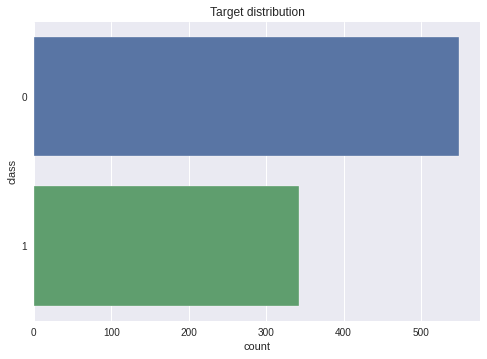

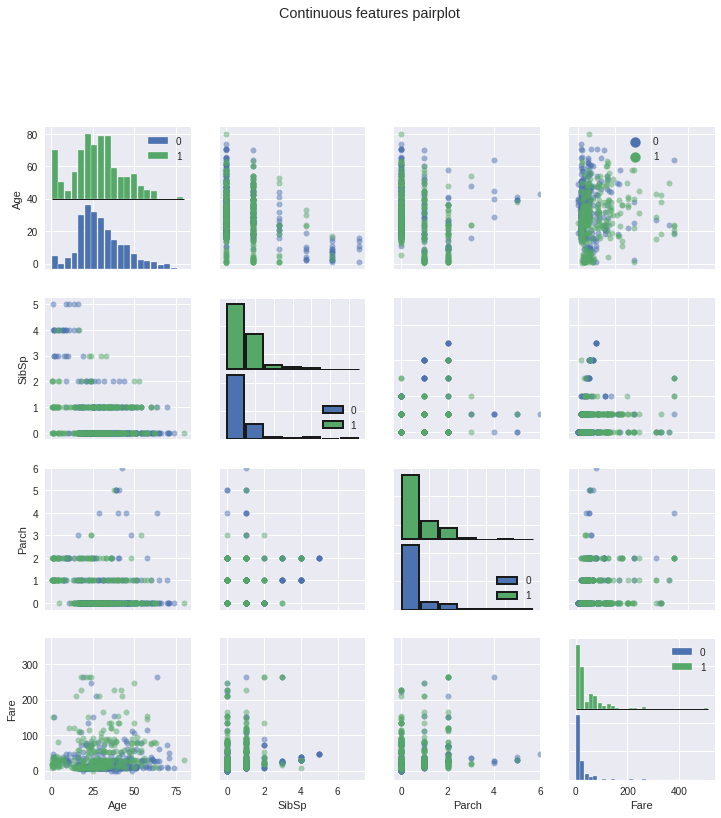

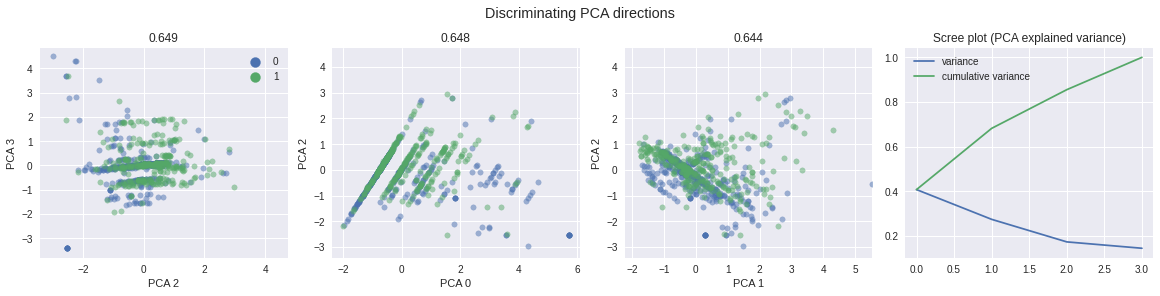

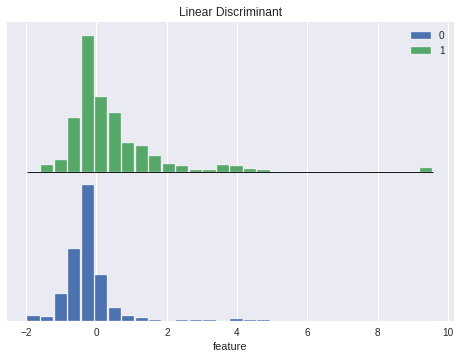

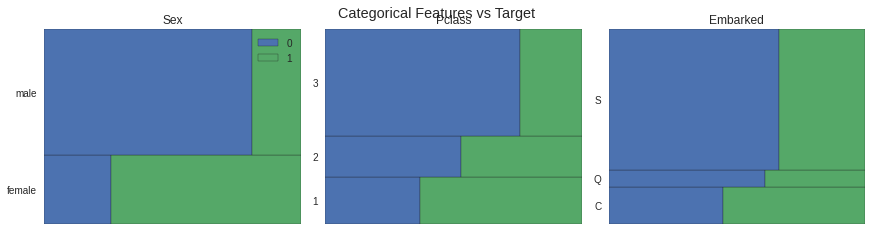

In [8]:
dabl.plot(df_train, target_col="Survived")

## 2.2 Missing values using MissingNo


ref.: https://towardsdatascience.com/visualize-missing-values-with-missingno-ad4d938b00a1


### Matrix form

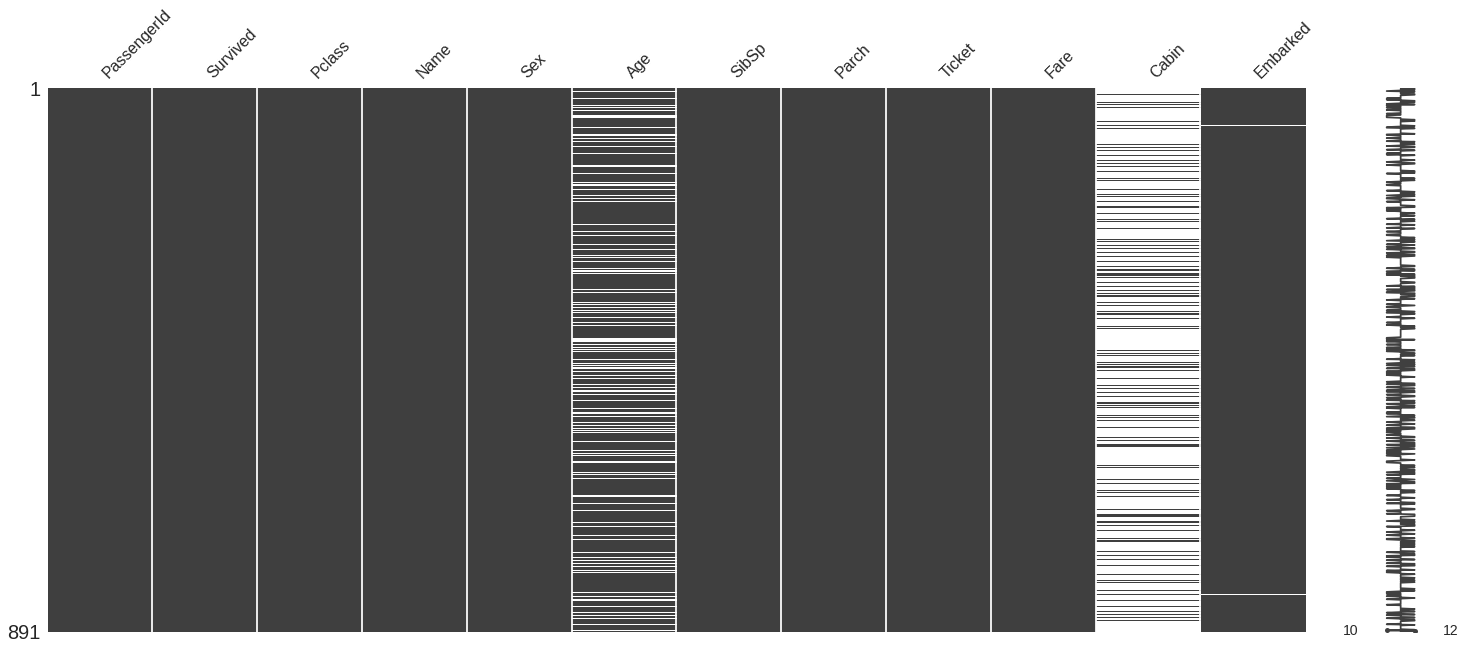

In [9]:
msno.matrix(df_train)

### Bar chart form

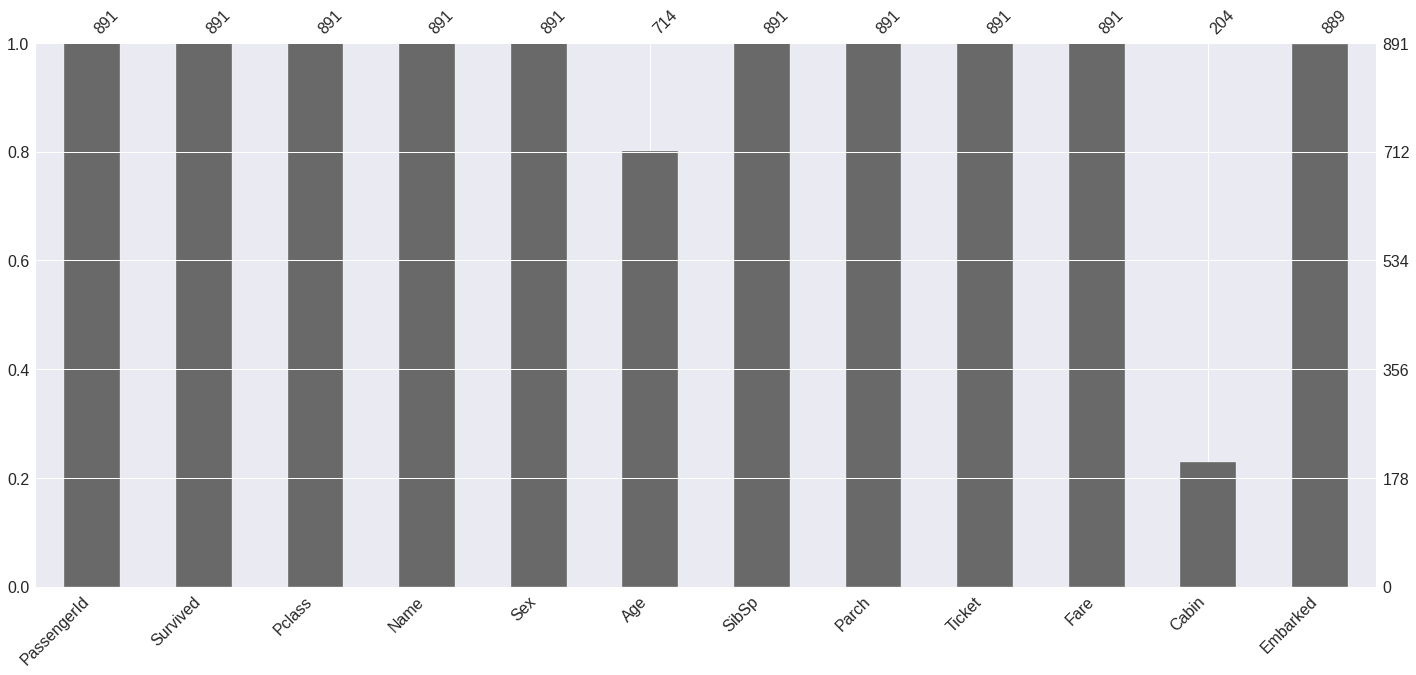

In [10]:
msno.bar(df_train)

### Correlation between missing values features

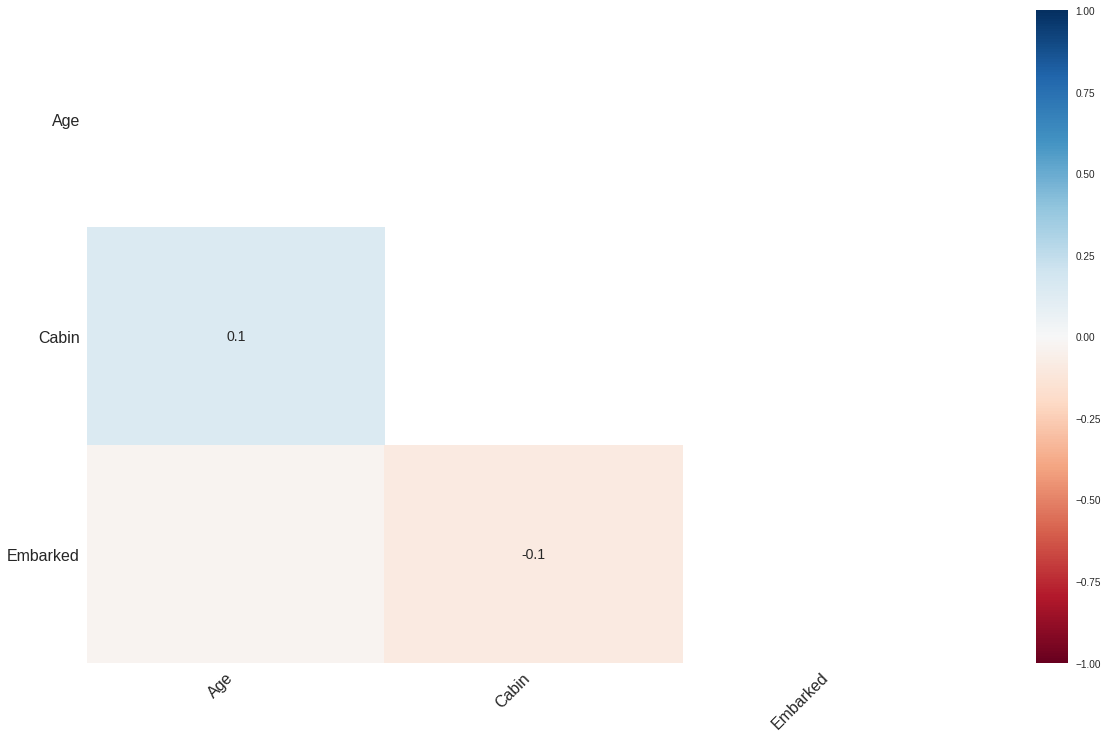

In [11]:
msno.heatmap(df_train)

## 2.3 Data visualization using AutoViz

ref.: https://towardsdatascience.com/autoviz-automatically-visualize-any-dataset-ba2691a8b55a

Shape of your Data Set: (891, 12)
Classifying variables in data set...
    11 Predictors classified...
        This does not include the Target column(s)
    4 variables removed since they were ID or low-information variables
Total Number of Scatter Plots = 3
Nothing to add Plot not being added
All plots done
Time to run AutoViz (in seconds) = 2.251


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,0
887,1,female,19.0,0,0,30.0000,S,1
888,3,female,0.0,1,2,23.4500,S,0
889,1,male,26.0,0,0,30.0000,C,1


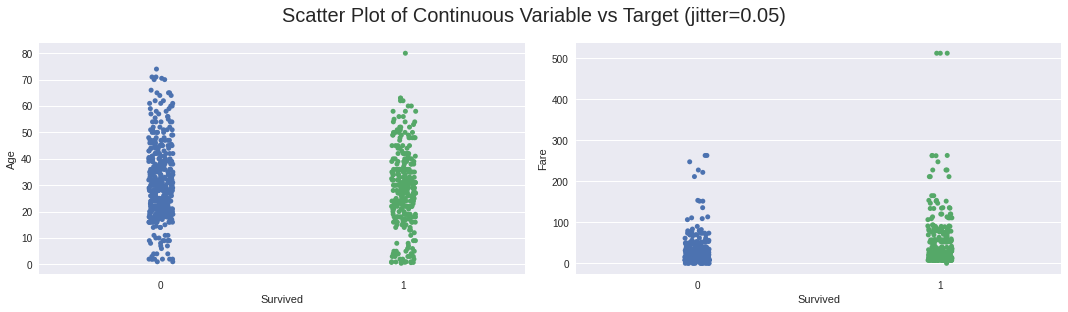

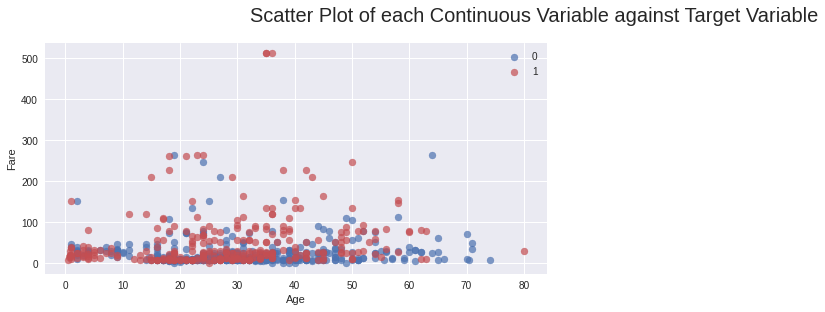

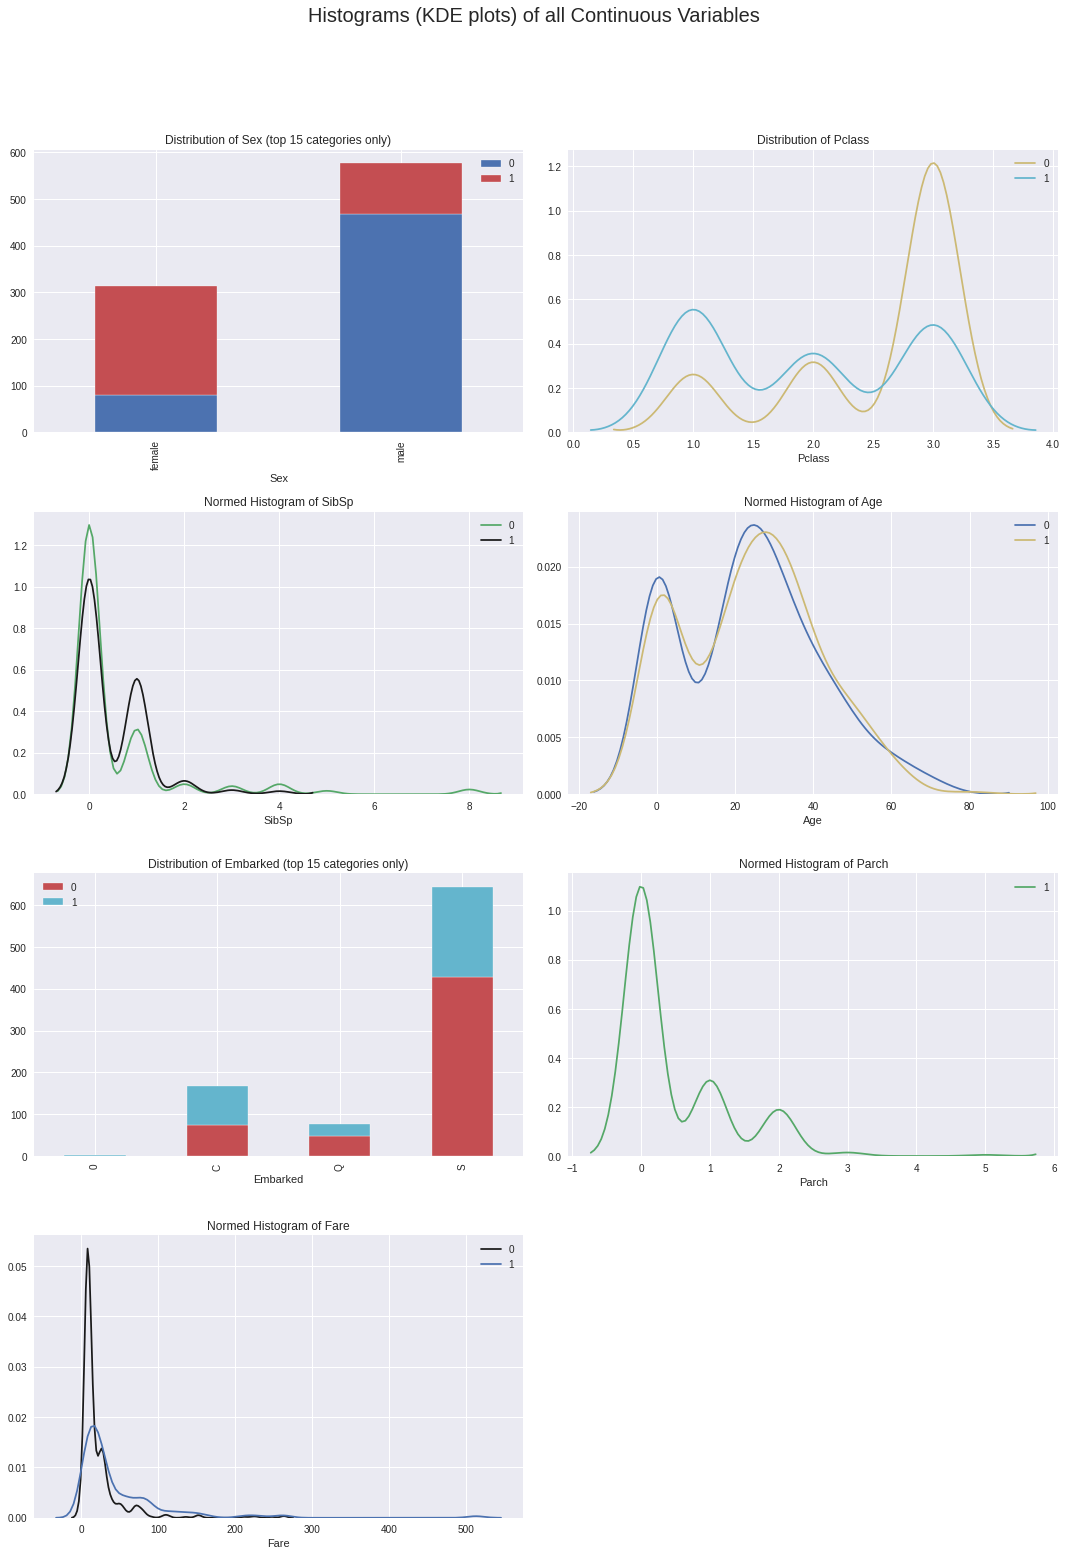

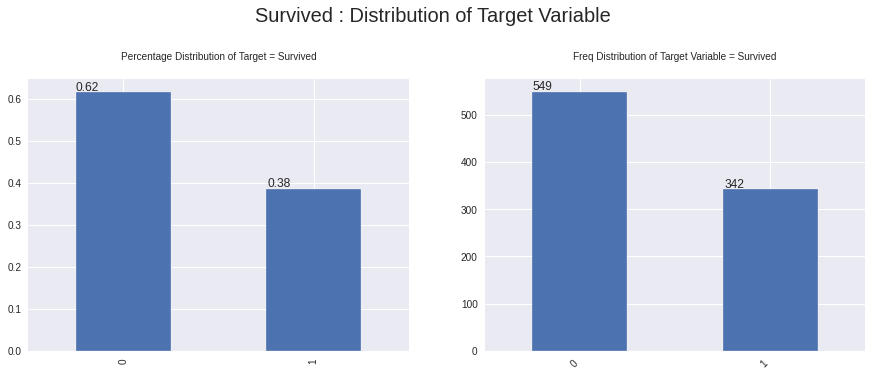

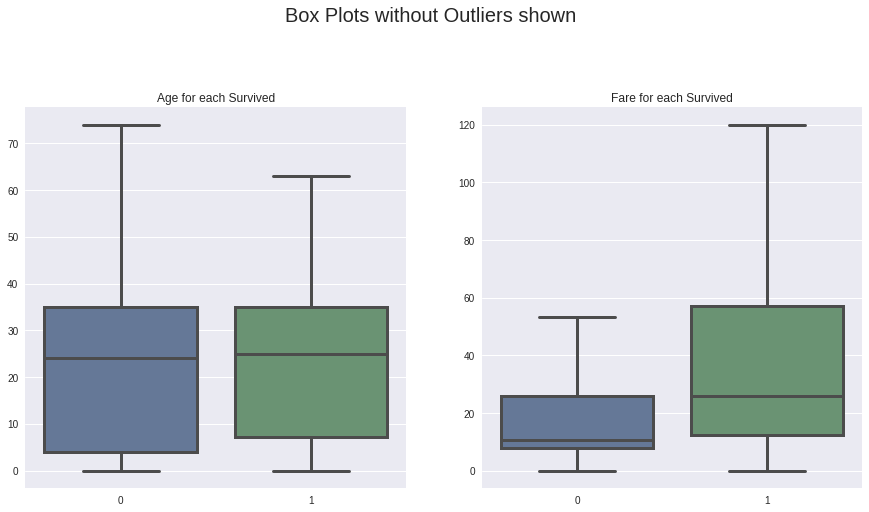

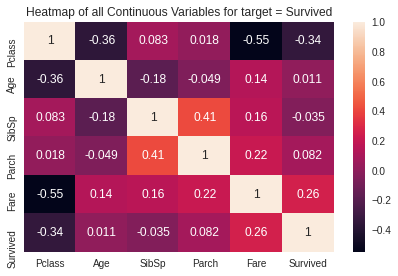

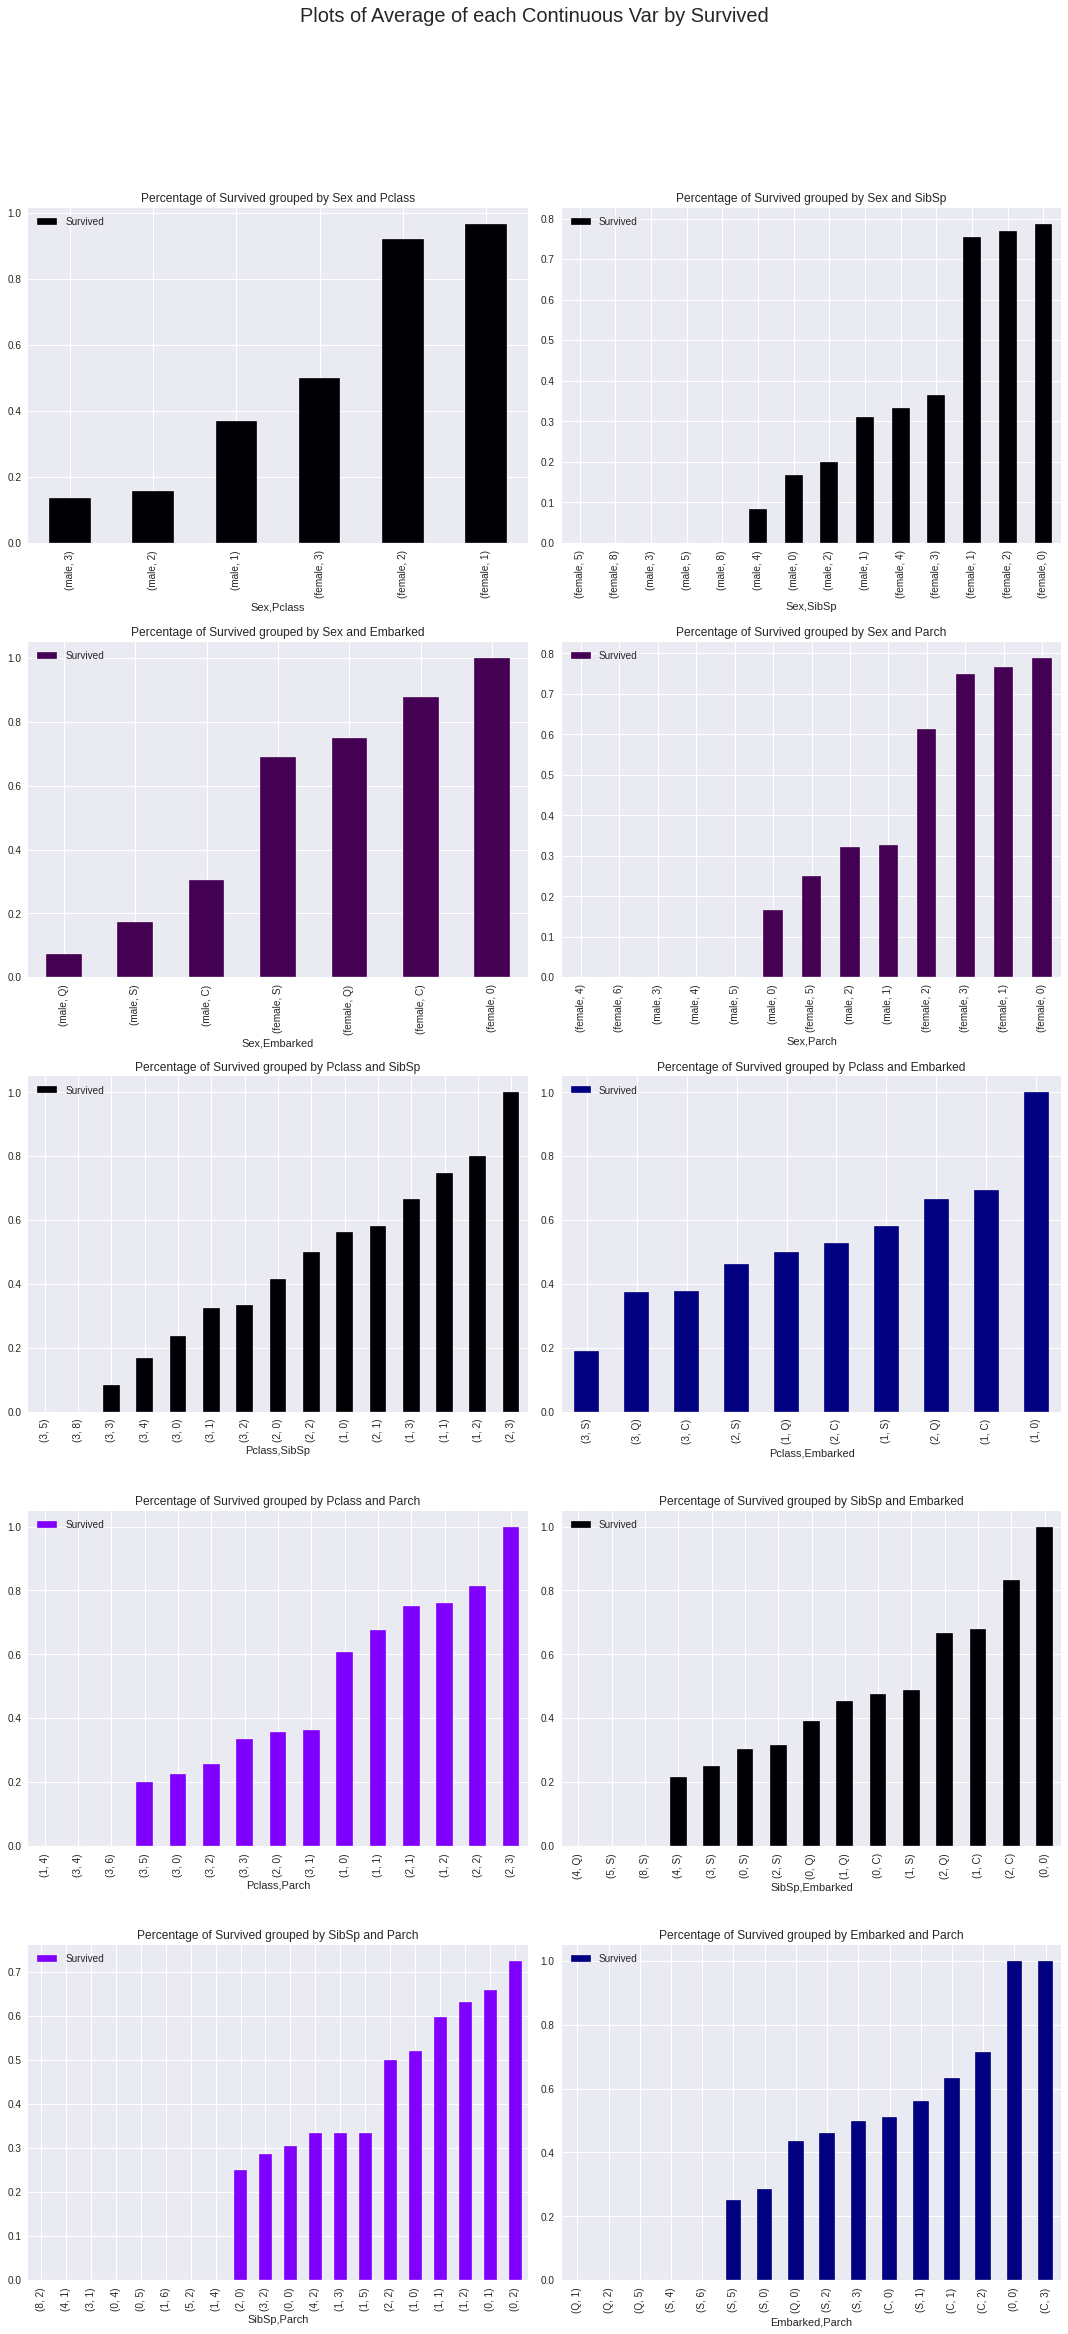

In [12]:
AV = AutoViz_Class()
AV.AutoViz('/kaggle/input/titanic/train.csv', depVar='Survived')


## 2.4 Using Predictive Power Score (PPS)

ref.: https://towardsdatascience.com/rip-correlation-introducing-the-predictive-power-score-3d90808b9598

In [13]:
matrix = pps.matrix(df_train)
matrix[matrix['y'] == 'Survived']

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
1,PassengerId,Survived,0.000000,regression,True,mean absolute error,0.383838,0.456813,DecisionTreeRegressor()
13,Survived,Survived,1.000000,predict_itself,True,None,0.000000,1.000000,None
25,Pclass,Survived,0.000000,regression,True,mean absolute error,0.383838,0.420680,DecisionTreeRegressor()
37,Name,Survived,0.000000,feature_is_id,True,None,0.000000,0.000000,None
49,Sex,Survived,0.129196,regression,True,mean absolute error,0.383838,0.334248,DecisionTreeRegressor()
61,Age,Survived,0.000000,regression,True,mean absolute error,0.406162,0.472346,DecisionTreeRegressor()
73,SibSp,Survived,0.000000,regression,True,mean absolute error,0.383838,0.454224,DecisionTreeRegressor()
85,Parch,Survived,0.000000,regression,True,mean absolute error,0.383838,0.461895,DecisionTreeRegressor()
97,Ticket,Survived,0.187650,regression,True,mean absolute error,0.383838,0.311811,DecisionTreeRegressor()
109,Fare,Survived,0.087345,regression,True,mean absolute error,0.383838,0.350312,DecisionTreeRegressor()


# 3. Preprocess

## 3.1 Feature engineering


### Create title feat.

In [14]:
def create_title_feat(df):
    df['Title'] = df['Name']

    # Cleaning name and extracting Title
    for name_string in df['Name']:
        df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.', expand=True)

    # Replacing rare titles with more common ones
    mapping = {'Mlle': 'Miss', 'Major': 'Mr', 'Col': 'Mr', 'Sir': 'Mr', 'Don': 'Mr', 'Mme': 'Miss',
              'Jonkheer': 'Mr', 'Lady': 'Mrs', 'Capt': 'Mr', 'Countess': 'Mrs', 'Ms': 'Miss', 'Dona': 'Mrs'}
    df.replace({'Title': mapping}, inplace=True)    


    
create_title_feat(df_train)
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


### Input missing age based on title

In [15]:
df_median_age = df_train.groupby(by=[ 'Title']).median().reset_index()
df_median_age = df_median_age[['Title', 'Age']]
df_median_age

,Title,Age
0,Dr,46.5
1,Master,3.5
2,Miss,21.5
3,Mr,30.0
4,Mrs,35.0
5,Rev,46.5


In [16]:
d = df_median_age.to_dict('list')
title = d['Title']
age = d['Age']

for t, a in zip(title, age):
    mask = (df_train['Title'] == t)
    df_train.loc[mask, 'Age'] = df_train.loc[mask, 'Age'].fillna(a)
    
df_train  

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr


### Create family size

In [17]:
def create_family_size(df):
    df['Family_Size'] = df['Parch'] + df['SibSp']
    
create_family_size(df_train)
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S,Miss,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,0


### Create age bins

In [18]:
def create_age_bins_feat(df):
    df['AgeBin'] = pd.qcut(df['Age'], 4)

create_age_bins_feat(df_train)
label = LabelEncoder()
df_train['AgeBin'] = label.fit_transform(df_train['AgeBin'])
df_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_Size,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S,Miss,3,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,0,1


# 4. Baseline algorithms

In [19]:
clf = classification.setup(df_train, 
                           target = 'Survived', 
                           ignore_features = ['Ticket', 'Name', 'PassengerId'], 
                           silent = True,
                           fix_imbalance = True,
                           session_id = 786)

Setup Succesfully Completed!


,Description,Value
0,session_id,786
1,Target Type,Binary
2,Label Encoded,"0: 0, 1: 1"
3,Original Data,"(891, 15)"
4,Missing Values,True
5,Numeric Features,3
6,Categorical Features,11
7,Ordinal Features,False
8,High Cardinality Features,False
9,High Cardinality Method,None


## 4.1 Compare models

In [20]:
# I'll use the _3_best_models in the future ...
_3_best_models = classification.compare_models(n_select=3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,Ridge Classifier,0.8299,0.0000,0.7612,0.7907,0.7733,0.6375,0.6402,0.0104
1,Gradient Boosting Classifier,0.8219,0.8826,0.7237,0.7965,0.7544,0.6158,0.6212,0.2487
2,Linear Discriminant Analysis,0.8218,0.8644,0.7529,0.7816,0.7634,0.6209,0.6250,0.0266
3,CatBoost Classifier,0.8203,0.8740,0.7112,0.7998,0.7498,0.6109,0.6162,1.9218
4,Logistic Regression,0.8187,0.8697,0.7987,0.7513,0.7710,0.6216,0.6264,0.0431
5,Light Gradient Boosting Machine,0.8059,0.8713,0.7196,0.7607,0.7370,0.5838,0.5870,0.0709
6,Extreme Gradient Boosting,0.8028,0.8652,0.7114,0.7582,0.7306,0.5760,0.5797,0.6696
7,Ada Boost Classifier,0.8026,0.8556,0.7529,0.7395,0.7433,0.5832,0.5864,0.1425
8,Random Forest Classifier,0.7945,0.8449,0.6567,0.7742,0.7068,0.5512,0.5586,0.1111
9,Extra Trees Classifier,0.7768,0.8320,0.6900,0.7219,0.7020,0.5243,0.5281,0.2531


## 4.2 2nd best model metrics
### I didn't understand the reason, but catboost did not allow all types of visualization, so I used the second best model to generate the graphics. If you know the reason and want to explain it to me, I appreciate it!

In [21]:
gbc = classification.create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8254,0.8472,0.7500,0.7826,0.7660,0.6268,0.6272
1,0.8571,0.9135,0.7500,0.8571,0.8000,0.6897,0.6934
2,0.7619,0.8328,0.6250,0.7143,0.6667,0.4828,0.4854
3,0.7903,0.8233,0.6957,0.7273,0.7111,0.5467,0.5470
4,0.8065,0.8997,0.5833,0.8750,0.7000,0.5654,0.5908
5,0.8548,0.9331,0.9167,0.7586,0.8302,0.7054,0.7150
6,0.7903,0.7961,0.6250,0.7895,0.6977,0.5405,0.5491
7,0.8871,0.9660,0.8333,0.8696,0.8511,0.7602,0.7607
8,0.8065,0.8920,0.7083,0.7727,0.7391,0.5857,0.5871
9,0.8387,0.9227,0.7500,0.8182,0.7826,0.6548,0.6564


### 4.2.1 Evaluate model

### Area Under the Curve

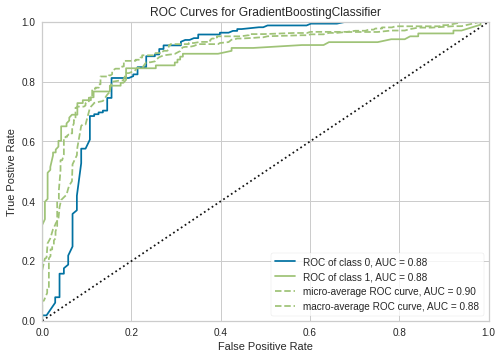

In [22]:
classification.plot_model(gbc, 'auc')

### Discrimination Threshold

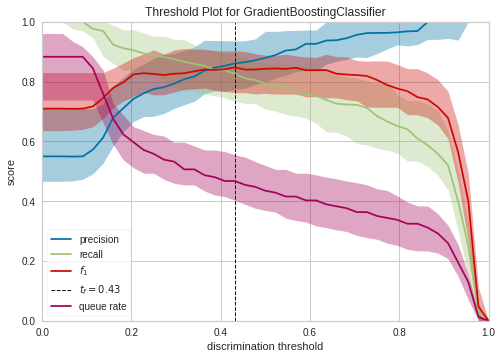

In [23]:
classification.plot_model(gbc, 'threshold')

### Precision Recall Curve

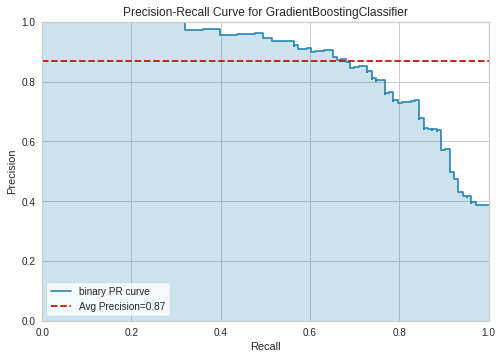

In [24]:
classification.plot_model(gbc, 'pr')

### Confusion Matrix

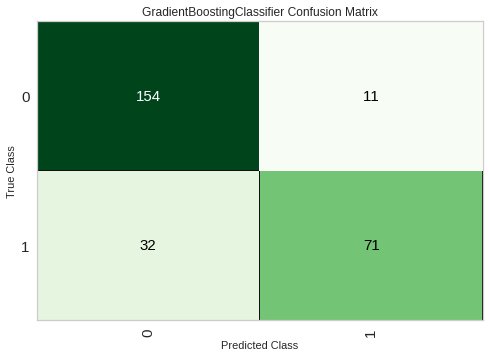

In [25]:
classification.plot_model(gbc, 'confusion_matrix')

### Class Prediction Error

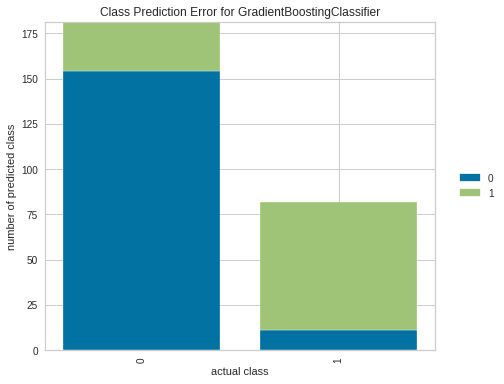

In [26]:
classification.plot_model(gbc, 'error')

### Classification Report

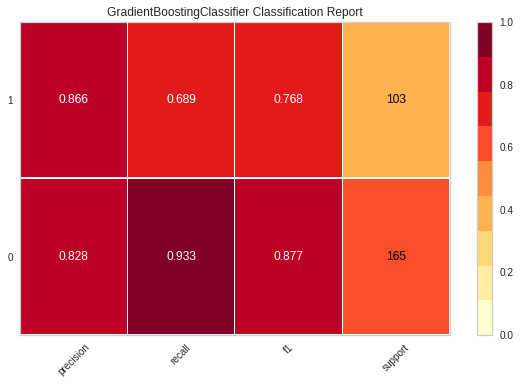

In [27]:
classification.plot_model(gbc, 'class_report')

### Decision Boundary

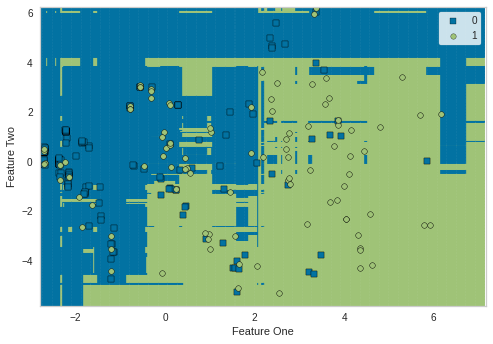

In [28]:
classification.plot_model(gbc, 'boundary')

### Learning Curve

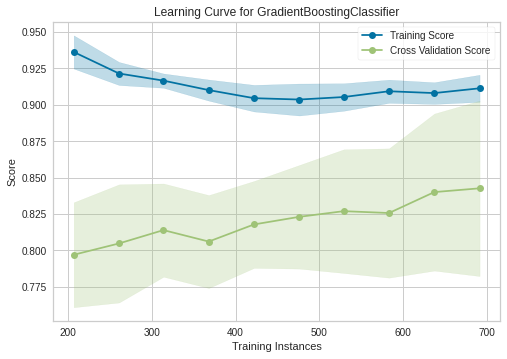

In [29]:
classification.plot_model(gbc, 'learning')

### Manifold Learning

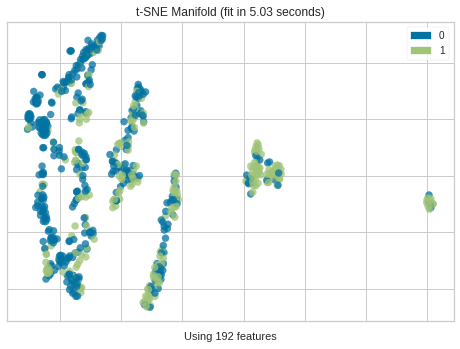

In [30]:
classification.plot_model(gbc, 'manifold')

### Calibration Curve

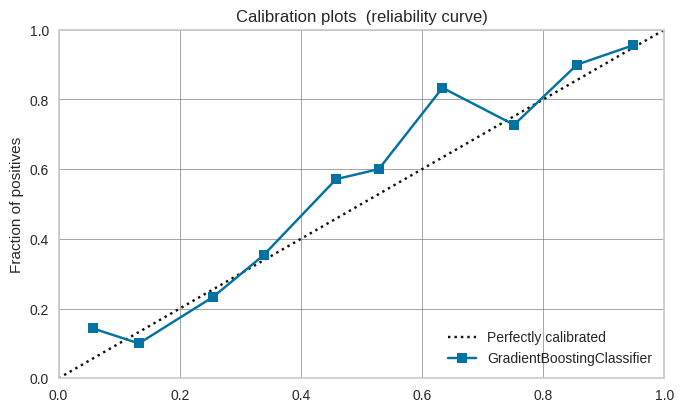

In [31]:
classification.plot_model(gbc, 'calibration')

### Validation Curve

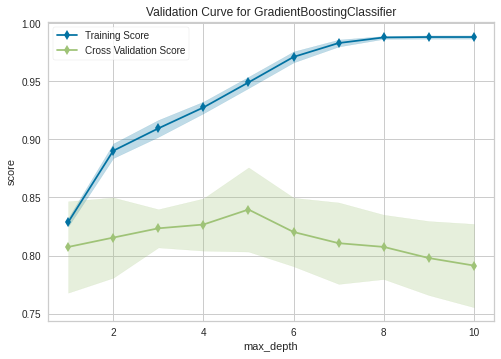

In [32]:
classification.plot_model(gbc, 'vc')

### Feature Importance

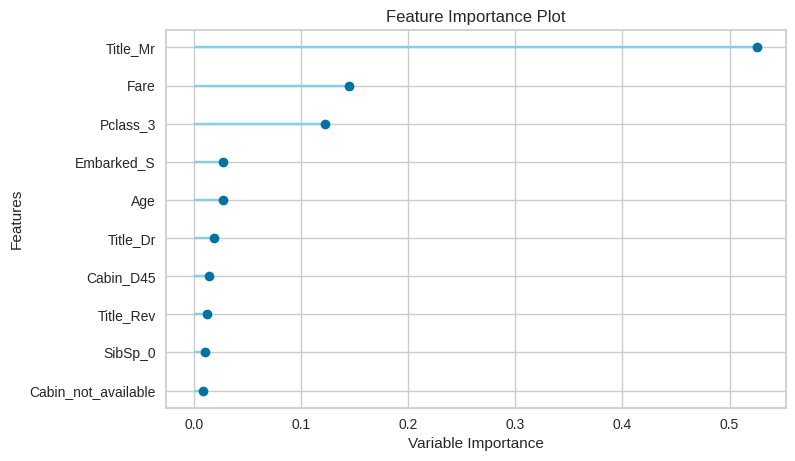

In [33]:
classification.plot_model(gbc, 'feature')

### Model Hyperparameter

In [34]:
classification.plot_model(gbc, 'parameter')

,Parameters
ccp_alpha,0
criterion,friedman_mse
init,None
learning_rate,0.1
loss,deviance
max_depth,3
max_features,None
max_leaf_nodes,None
min_impurity_decrease,0
min_impurity_split,None


### Dimension Learning
#### I don't know what that means, if you can explain it to me, I really appreciate it!

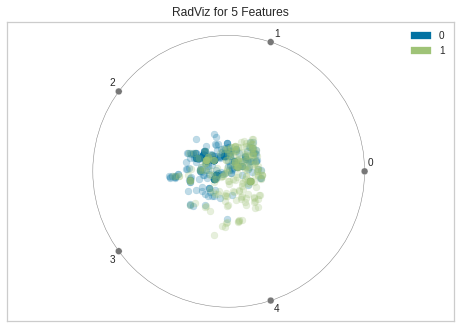

In [35]:
classification.plot_model(gbc, 'dimension')

## 4.3 Interpret results

### 4.3.1 Shap values

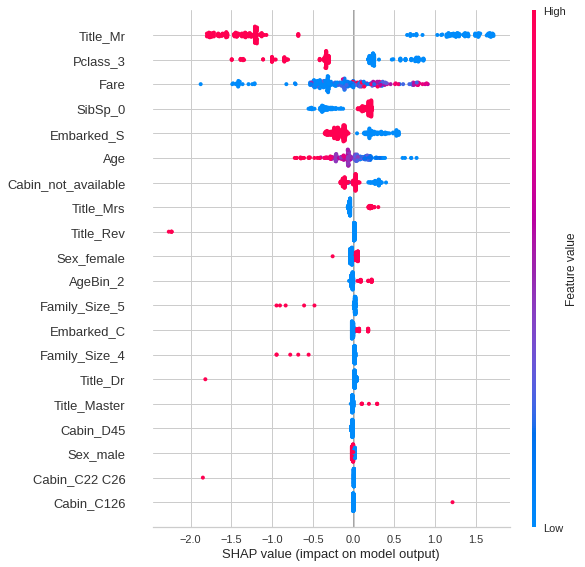

In [36]:
classification.interpret_model(gbc)

### 4.3.2 Correlation Plot
#### I need more information about it... if you want to help me improve this result, I appreciate it!

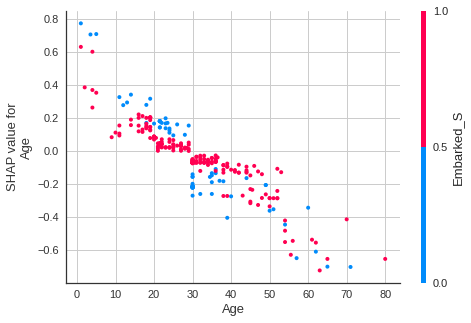

In [37]:
classification.interpret_model(gbc, plot = 'correlation')

### 4.3.3 Plot at Observation Level

In [38]:
classification.interpret_model(gbc, plot = 'reason', observation = 50)

# 5. Improve results
## (I'll try at least ...)

## 5.1 Blend models
### I'll blend the 3 best models, as a way to improve the model's results (yeah... i'll use "3_best_models" variable now...)

In [39]:
# train a votingclassifier on all models in library
clf = classification.blend_models(estimator_list=_3_best_models, method = 'hard')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8095,0.0000,0.7500,0.7500,0.7500,0.5962,0.5962
1,0.8889,0.0000,0.8333,0.8696,0.8511,0.7625,0.7630
2,0.7778,0.0000,0.6667,0.7273,0.6957,0.5212,0.5224
3,0.7742,0.0000,0.6957,0.6957,0.6957,0.5162,0.5162
4,0.8710,0.0000,0.7500,0.9000,0.8182,0.7195,0.7266
5,0.8387,0.0000,0.8750,0.7500,0.8077,0.6702,0.6761
6,0.8065,0.0000,0.6250,0.8333,0.7143,0.5724,0.5860
7,0.8548,0.0000,0.8333,0.8000,0.8163,0.6964,0.6968
8,0.8065,0.0000,0.7083,0.7727,0.7391,0.5857,0.5871
9,0.8387,0.0000,0.7917,0.7917,0.7917,0.6601,0.6601


## 5.2 Optimize threshold

In [40]:
classification.optimize_threshold(gbc, false_positive = -10, false_negative = -10, true_negative = 10, true_positive = 10)

Optimized Probability Threshold: 0.42 | Optimized Cost Function: 1860


## 5.3 New predict model

In [41]:
classification.predict_model(gbc, probability_threshold=0.42)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.847,0.876,0.7282,0.8523,0.7853,0.6676,0.6726


,Age,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,SibSp_2,...,Family_Size_5,Family_Size_6,Family_Size_7,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,Survived,Label,Score
0,18.0,14.4542,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,1,0.7307
1,22.0,7.7500,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,1,0.4704
2,18.0,13.0000,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.9281
3,80.0,30.0000,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0,0.1810
4,33.0,7.7750,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0.1420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,30.0,14.4583,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0.1436
264,61.0,6.2375,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.0378
265,52.0,13.0000,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0.1190
266,1.0,15.7417,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1,0.9198


# 6. Finilize model (submit results)

In [42]:
df_test = pd.read_csv('/kaggle/input/titanic/test.csv')
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [43]:
create_title_feat(df_test)
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Mrs
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Mr


In [44]:
d = df_median_age.to_dict('list')
title = d['Title']
age = d['Age']

for t, a in zip(title, age):
    mask = (df_test['Title'] == t)
    df_test.loc[mask, 'Age'] = df_test.loc[mask, 'Age'].fillna(a)
    
df_test  

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.0,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Mrs
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,1308,3,"Ware, Mr. Frederick",male,30.0,0,0,359309,8.0500,NaN,S,Mr


In [45]:
create_family_size(df_test)
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_Size
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.0,0,0,A.5. 3236,8.0500,NaN,S,Mr,0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Mrs,0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr,0
416,1308,3,"Ware, Mr. Frederick",male,30.0,0,0,359309,8.0500,NaN,S,Mr,0


In [46]:
create_age_bins_feat(df_test)
label = LabelEncoder()
df_test['AgeBin'] = label.fit_transform(df_test['AgeBin'])
df_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_Size,AgeBin
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,0,2
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,1,3
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,0,3
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.0,0,0,A.5. 3236,8.0500,NaN,S,Mr,0,1
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Mrs,0,3
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr,0,3
416,1308,3,"Ware, Mr. Frederick",male,30.0,0,0,359309,8.0500,NaN,S,Mr,0,1


In [47]:
result = classification.predict_model(gbc, data=df_test)
result

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Family_Size,AgeBin,Label,Score
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,0,2,0,0.1464
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,1,3,0,0.1382
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,0,3,0,0.0955
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,0,1,0,0.1455
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,2,1,0,0.4086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30.0,0,0,A.5. 3236,8.0500,NaN,S,Mr,0,1,0,0.1455
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Mrs,0,3,1,0.9693
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr,0,3,0,0.1153
416,1308,3,"Ware, Mr. Frederick",male,30.0,0,0,359309,8.0500,NaN,S,Mr,0,1,0,0.1455


In [48]:
result = result[['PassengerId', 'Label']]
result.rename(columns = {'Label': 'Survived'}, inplace = True)
result.to_csv('submission.csv', index=False, header=True)

![thats all folks](https://i.pinimg.com/originals/2c/2e/ef/2c2eef8da1285d958914eef079f9b70c.jpg)